In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy import stats

R2 base model: 0.011510745596695737
R2 interaction model: 0.017804933119713207
F-statistic: 17.53, p = 2.9127294468467548e-05


/tmp/ipykernel_499/1082462754.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, grp in df.groupby('logP_quartile'):


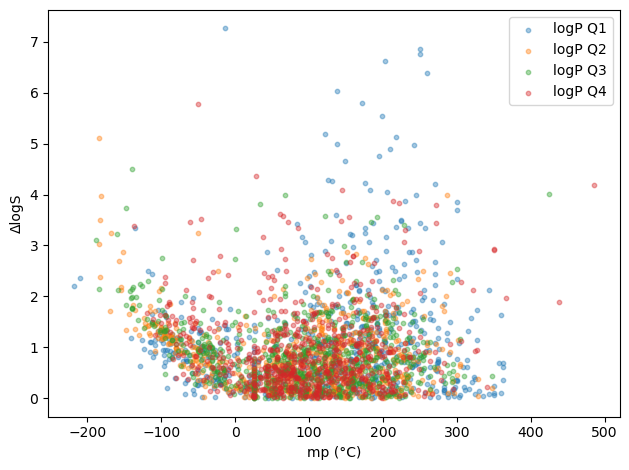

In [2]:
df = pd.read_csv('SolCbio3Database_merged.csv')

df['mp_logP_interaction'] = df['mp']*df['logPN']

# Fit linear models with and without interaction
X_base = df[['mp', 'logPN']]
X_inter = df[['mp', 'logPN', 'mp_logP_interaction']]
y = df['diff_logS']


from sklearn.metrics import r2_score
lm_base = LinearRegression().fit(X_base, y)
lm_inter = LinearRegression().fit(X_inter, y)

print('R2 base model:', r2_score(y, lm_base.predict(X_base)))
print('R2 interaction model:', r2_score(y, lm_inter.predict(X_inter)))


# F-test for significance of interaction term
from scipy.stats import f
rss_base = np.sum((y - lm_base.predict(X_base))**2)
rss_inter = np.sum((y - lm_inter.predict(X_inter))**2)
f_stat = ((rss_base - rss_inter)/1) / (rss_inter/(len(y)-4))
print(f'F-statistic: {f_stat:.2f}, p = {f.sf(f_stat, 1, len(y)-4)}')



# Visualise: ΔlogS vs mp coloured by logP quartile
import matplotlib.pyplot as plt
df['logP_quartile'] = pd.qcut(df['logPN'], 4, labels=['Q1','Q2','Q3','Q4'])
for q, grp in df.groupby('logP_quartile'):
    plt.scatter(grp['mp'], grp['diff_logS'], label=f'logP {q}', alpha=0.4, s=10)
plt.xlabel('mp (°C)'); plt.ylabel('ΔlogS'); plt.legend(); plt.tight_layout()
plt.savefig('mp_logP_interaction.png', dpi=300)
plt.savefig('mp_logP_interaction.pdf', dpi=300)


In [7]:
df

,id,Compound,smiles,CAS_RN,logS,Ref_logS,mp,Ref_mp,logPN,Ref_logP,GSE,diff_logS,mp_logP_interaction,logP_quartile
0,SolCbio3-1,Octacholodibenzo-p-dioxin,Clc1c(Cl)c(Cl)c2c(c1Cl)Oc1c(Cl)c(Cl)c(Cl)c(Cl)...,3268-87-9,-12.79,10.1016/S0045-6535(02)00118-20.10.1016/S0045-6...,322.0,10.1016/S0045-6535(02)00118-20.10.1016/S0045-6...,8.200,PubChem,-10.670,2.120,2640.40,Q4
1,SolCbio3-2,"2,3,7,8-Tetrachlorodibenzo-p-dioxin",Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,1746-01-6,-10.22,10.1016/S0045-6535(02)00118-20.10.1016/S0045-6...,305.0,10.1016/S0045-6535(02)00118-20.10.1016/S0045-6...,6.800,Kenneth,-9.100,1.120,2074.00,Q4
2,SolCbio3-3,"2,2',3,4,4',5,5'-Heptachlorodiphenyl ether",Clc1cc(Cl)c(Oc2cc(Cl)c(Cl)c(Cl)c2Cl)cc1Cl,83992-69-2,-9.50,10.1016/S0045-6535(02)00118-20.10.1016/S0045-6...,89.0,10.1016/S0045-6535(02)00118-2,7.460,Kenneth,-7.600,1.900,663.94,Q4
3,SolCbio3-4,"1,2,3,4,7-Pentachlorodibenzo-p-dioxin",Clc1ccc2c(c1)Oc1c(Cl)c(Cl)c(Cl)c(Cl)c1O2,39227-61-7,-9.48,10.1016/S0045-6535(02)00118-2,195.0,10.1016/S0045-6535(02)00118-2,7.400,Kenneth,-8.600,0.880,1443.00,Q4
4,SolCbio3-5,"2,3,3',4,4',5,6-Heptachlorodiphenyl ether",Clc1ccc(Oc2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl)cc1Cl,83992-70-5,-9.46,10.1016/S0045-6535(02)00118-2,169.0,10.1016/S0045-6535(02)00118-2,7.310,Kenneth,-8.250,1.210,1235.39,Q4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2735,SolCbio3-2736,Gemcitabine,Nc1ccn([C@@H]2O[C@H](CO)[C@@H](O)C2(F)F)c(=O)n1,NaN,-1.24,avdeef,169.0,avdeef,-1.400,Kenneth,0.460,1.700,-236.60,Q1
2736,SolCbio3-2737,2'-Deoxyadenosine,Nc1ncnc2c1ncn2[C@H]1C[C@H](O)[C@@H](CO)O1,NaN,-1.59,avdeef,189.0,avdeef,-0.550,PubChem,-0.590,1.000,-103.95,Q1
2737,SolCbio3-2738,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NaN,-1.73,avdeef,235.0,avdeef,-1.050,Kenneth,-0.550,1.180,-246.75,Q1
2738,SolCbio3-2739,Vidarabine<Adenosinestereoisomer>,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,NaN,-2.82,avdeef,234.0,avdeef,-2.115,Kenneth,0.525,3.345,-494.91,Q1
